In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import warnings
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, lognorm, gamma

warnings.simplefilter(action="ignore", category=FutureWarning)

# Voeg de src-folder toe aan je Python path
src_path = Path("../src").resolve()
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from dataloader import load_data
from config import Config


In [7]:
config_path = Path("../config.toml").resolve()
config = Config.load(config_path)
df = load_data(config)

df

,timestamp,message,author,age,gender
0,2013-08-17 10:14:17,‎Loïs Vriens heeft deze groep gemaakt\n,good-natured-ermine,25.0,f
1,2023-08-16 19:50:13,‎Bram Van Den Oever heeft je toegevoegd\n,furry-binturong,NaN,None
2,2023-08-16 19:59:39,‎Dit bericht is verwijderd.\n,good-natured-ermine,25.0,f
3,2023-08-16 20:00:35,‎ ‎GIF weggelaten\n,good-natured-ermine,25.0,f
4,2023-08-16 20:07:02,Klasse goed bezig 😁\n,snappy-ermine,30.0,m
...,...,...,...,...,...
9893,2025-03-16 17:16:14,"Thanks 😊\nFf tussenstop op Tenerife, crew wis...",crystalline-turkey,37.0,m
9894,2025-03-16 22:33:05,"Wij zijn weer in Nederland, net de wieltjes w...",crystalline-turkey,37.0,m
9895,2025-03-17 07:24:32,Welcome back! 💪🏻\n,groovy-salmon,35.0,m
9896,2025-03-17 15:14:03,‎ ‎afbeelding weggelaten\n,good-natured-ermine,25.0,f


In [9]:
# timestamp goed zetten
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date

# selecteer periode vóór carnaval 2024
start_carnaval = pd.to_datetime('2024-02-08').date()
begin = start_carnaval - pd.Timedelta(days=14)
eind = start_carnaval

df_carnaval = df[(df['date'] >= begin) & (df['date'] <= eind)].copy()

# tel aantal berichten per dag
daily_counts = df_carnaval.groupby('date').size().reset_index(name='message_count')

# zet om naar "dagen tot carnaval"
daily_counts['dagen_tot_carnaval'] = (pd.to_datetime(daily_counts['date']) - pd.to_datetime(start_carnaval)).dt.days

daily_counts

,date,message_count,dagen_tot_carnaval
0,2024-01-25,22,-14
1,2024-01-26,25,-13
2,2024-01-27,11,-12
3,2024-01-30,2,-9
4,2024-01-31,13,-8
5,2024-02-01,25,-7
6,2024-02-02,24,-6
7,2024-02-03,78,-5
8,2024-02-04,27,-4
9,2024-02-06,4,-2


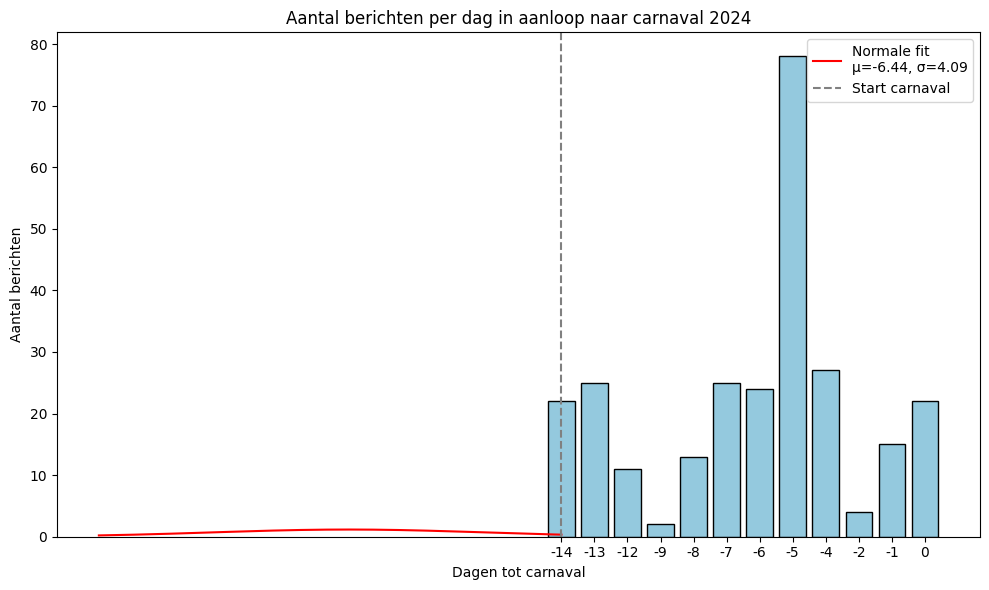

In [10]:
# Fit een normale verdeling
x = daily_counts['dagen_tot_carnaval']
y = daily_counts['message_count']

mu, std = norm.fit(x.repeat(y))  # weeg mee hoe vaak iets voorkomt

# Stap 6: Plot histogram + fitted curve
plt.figure(figsize=(10, 6))
sns.barplot(x='dagen_tot_carnaval', y='message_count', data=daily_counts, color='skyblue', edgecolor='black')

# Normale verdeling tekenen
x_vals = np.linspace(x.min(), x.max(), 200)
fitted_y = norm.pdf(x_vals, mu, std) * len(x) * (1 / (std * np.sqrt(2 * np.pi))) * std * 2.5  # schalen

plt.plot(x_vals, fitted_y, color='red', label=f'Normale fit\nμ={mu:.2f}, σ={std:.2f}')
plt.axvline(0, linestyle='--', color='gray', label='Start carnaval')
plt.title('Aantal berichten per dag in aanloop naar carnaval 2024')
plt.xlabel('Dagen tot carnaval')
plt.ylabel('Aantal berichten')
plt.legend()
plt.tight_layout()
plt.show()

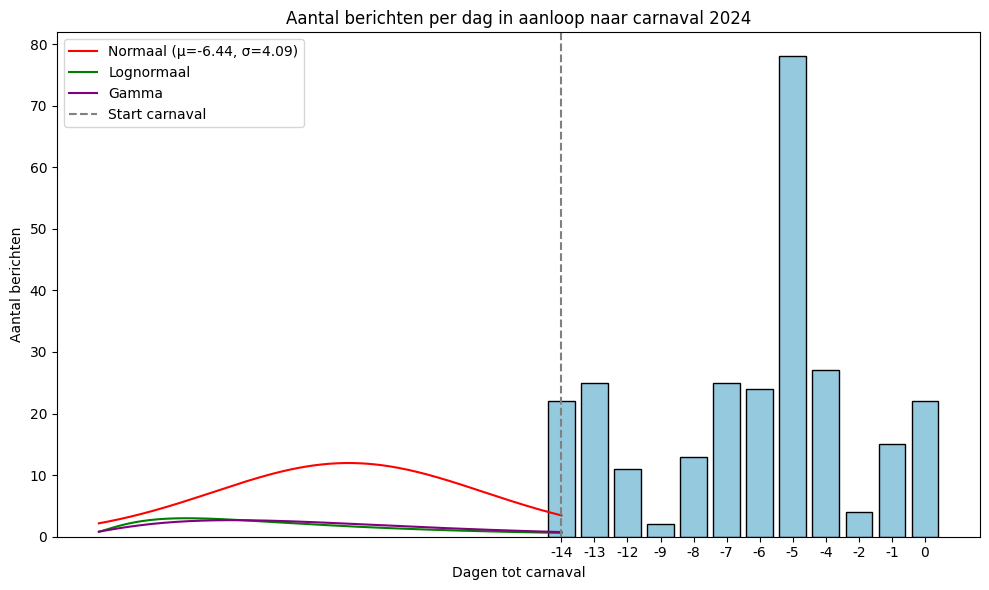

In [13]:
# Aantal berichten per dag
daily_counts = df_carnaval.groupby('date').size().reset_index(name='message_count')
daily_counts['dagen_tot_carnaval'] = (pd.to_datetime(daily_counts['date']) - pd.to_datetime(start_carnaval)).dt.days

# Voor fitting: herhaal dagen obv message_count
x = daily_counts['dagen_tot_carnaval']
y = daily_counts['message_count']
x_weighted = x.repeat(y)

# Normale fit
mu_norm, std_norm = norm.fit(x_weighted)

# Lognormale fit — vereist alleen positieve waarden
x_shift = x_weighted.min() - 1  # bijv. -14 wordt +1
x_lognorm = x_weighted - x_shift
shape_ln, loc_ln, scale_ln = lognorm.fit(x_lognorm, floc=0)

# Gamma fit — ook alleen positief
shape_g, loc_g, scale_g = gamma.fit(x_lognorm, floc=0)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='dagen_tot_carnaval', y='message_count', data=daily_counts, color='skyblue', edgecolor='black')

# X-waarden voor curve
x_vals = np.linspace(x.min(), x.max(), 300)

# Curves berekenen
y_norm = norm.pdf(x_vals, mu_norm, std_norm) * len(x) * std_norm * 2.5
y_lognorm = lognorm.pdf(x_vals - x_shift, shape_ln, loc_ln, scale_ln) * len(x) * 2.5
y_gamma = gamma.pdf(x_vals - x_shift, shape_g, loc_g, scale_g) * len(x) * 2.5

# Plot curves
plt.plot(x_vals, y_norm, color='red', label=f'Normaal (μ={mu_norm:.2f}, σ={std_norm:.2f})')
plt.plot(x_vals, y_lognorm, color='green', label='Lognormaal')
plt.plot(x_vals, y_gamma, color='purple', label='Gamma')

plt.axvline(0, linestyle='--', color='gray', label='Start carnaval')
plt.title('Aantal berichten per dag in aanloop naar carnaval 2024')
plt.xlabel('Dagen tot carnaval')
plt.ylabel('Aantal berichten')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
import re

# Unicode regex voor emoji’s
EMOJI_REGEX = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbolen & pictogrammen
    "\U0001F680-\U0001F6FF"  # transport & kaarten
    "\U0001F1E0-\U0001F1FF"  # vlaggen
    "\U00002700-\U000027BF"  # diverse symbolen
    "\U0001F900-\U0001F9FF"  # extra emoticons
    "\U0001FA70-\U0001FAFF"  # meer symbolen
    "]+",
    flags=re.UNICODE
)

# Functie om emoji’s te tellen
def count_emojis(text):
    if isinstance(text, str):
        return len(EMOJI_REGEX.findall(text))
    return 0

# Emoji's tellen per bericht
df['emoji_count'] = df['message'].apply(count_emojis)

df


,timestamp,message,author,age,gender,date,emoji_count
0,2013-08-17 10:14:17,‎Loïs Vriens heeft deze groep gemaakt\n,good-natured-ermine,25.0,f,2013-08-17,0
1,2023-08-16 19:50:13,‎Bram Van Den Oever heeft je toegevoegd\n,furry-binturong,NaN,None,2023-08-16,0
2,2023-08-16 19:59:39,‎Dit bericht is verwijderd.\n,good-natured-ermine,25.0,f,2023-08-16,0
3,2023-08-16 20:00:35,‎ ‎GIF weggelaten\n,good-natured-ermine,25.0,f,2023-08-16,0
4,2023-08-16 20:07:02,Klasse goed bezig 😁\n,snappy-ermine,30.0,m,2023-08-16,1
...,...,...,...,...,...,...,...
9893,2025-03-16 17:16:14,"Thanks 😊\nFf tussenstop op Tenerife, crew wis...",crystalline-turkey,37.0,m,2025-03-16,2
9894,2025-03-16 22:33:05,"Wij zijn weer in Nederland, net de wieltjes w...",crystalline-turkey,37.0,m,2025-03-16,0
9895,2025-03-17 07:24:32,Welcome back! 💪🏻\n,groovy-salmon,35.0,m,2025-03-17,1
9896,2025-03-17 15:14:03,‎ ‎afbeelding weggelaten\n,good-natured-ermine,25.0,f,2025-03-17,0


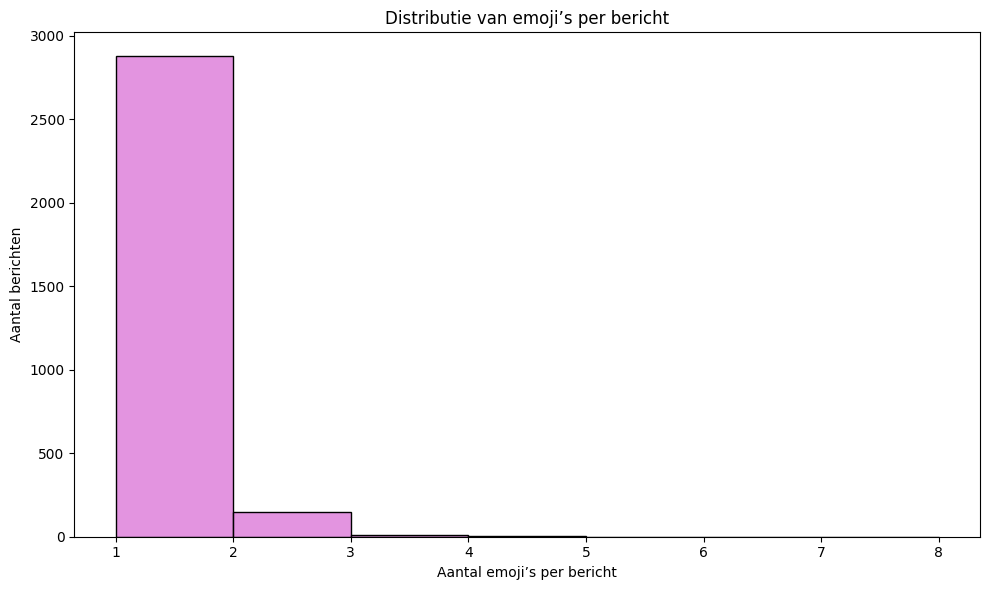

In [18]:
# Filter alleen berichten met minstens 1 emoji
emoji_df = df[df['emoji_count'] > 0]

plt.figure(figsize=(10,6))
sns.histplot(emoji_df['emoji_count'], bins=range(1, emoji_df['emoji_count'].max()+2), kde=False, color='orchid', edgecolor='black')
plt.title('Distributie van emoji’s per bericht')
plt.xlabel('Aantal emoji’s per bericht')
plt.ylabel('Aantal berichten')
plt.tight_layout()
plt.show()

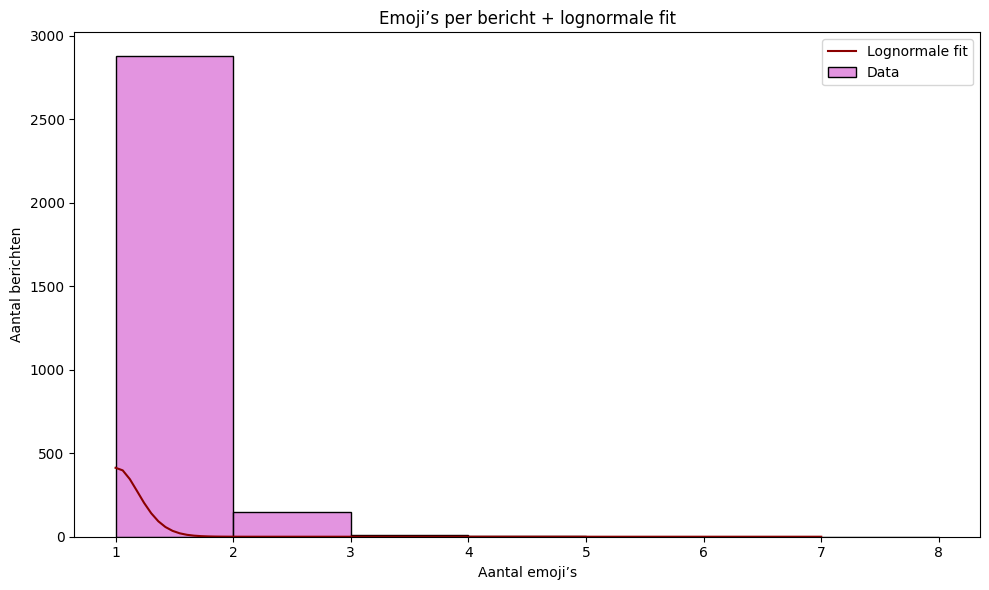

In [19]:
from scipy.stats import lognorm

# Fit een lognormale verdeling (alle waarden > 0)
data = emoji_df['emoji_count']
shape, loc, scale = lognorm.fit(data, floc=0)

# Plot met fitted curve
x_vals = np.linspace(data.min(), data.max(), 100)
y_fit = lognorm.pdf(x_vals, shape, loc, scale) * len(data) * (x_vals[1]-x_vals[0])  # schaal naar histogram

plt.figure(figsize=(10,6))
sns.histplot(data, bins=range(1, data.max()+2), stat='count', color='orchid', edgecolor='black', label='Data')
plt.plot(x_vals, y_fit, color='darkred', label='Lognormale fit')
plt.title('Emoji’s per bericht + lognormale fit')
plt.xlabel('Aantal emoji’s')
plt.ylabel('Aantal berichten')
plt.legend()
plt.tight_layout()
plt.show()
